# Salmon Instance Segmentation and Tracking

Part of **Computer Vision for Salmon**: a Google Colab experiment in underwater instance segmentation and short-term multi-object tracking.

## Objectives
- Prepare and inspect custom salmon polygon annotations.
- Fine-tune pretrained YOLO26s-seg weights.
- Evaluate boxes and masks on a validation split.
- Apply segmentation and ByteTrack to consecutive video frames.

## Data and experimental scope
The project author annotated 43 images from the BoostCompTrack CS and TBW training folders using Ultralytics Platform. Source imagery includes GH010031 and cage 15 footage. Rotated images may include black padding; fish proportions were retained.

| Split | Images | Instance polygons |
|---|---:|---:|
| Training | 35 | 713 |
| Validation | 8 | 184 |
| Total | 43 | 897 |

All instances use class `0: salmon`. Training and validation contain frames from the same source recordings. **There is no independent segmentation test set.** GH010031 video previews are qualitative demonstrations on a familiar recording, not independent generalization tests.

## Reproduction and dependencies
Use Google Colab with a GPU runtime. Dataset files, custom annotations, videos, and trained weights are not bundled with this notebook. Exact reproduction requires the original custom annotations and split assignments. An NDJSON export references remotely hosted images; expired download links require a fresh export.

Run cells in order for data preparation. Training is disabled by default: set `RUN_TRAINING = True` deliberately to start a new experiment. For inference with existing weights, run setup and configuration, then skip directly to section 6 or 7.

Saved metrics and the retained training curve document the original September 19, 2026 experiment. The edited notebook has been checked statically but has not been rerun. Source-image outputs were cleared; preview cells regenerate them when executed.

## Attribution
- [BoostCompTrack dataset](https://zenodo.org/records/16880877)
- [BoostCompTrack research](https://arxiv.org/abs/2509.25969)
- [Ultralytics](https://docs.ultralytics.com/)
- [ByteTrack](https://github.com/ifzhang/ByteTrack)

Implementation was developed with AI-assisted coding support. Dataset annotation, experiment execution, and visual assessment were performed by the project author. Source data and software retain their respective licenses.

## 1. Environment setup
Install the experiment's Ultralytics version and tracking dependency. Colab supplies PyTorch; its version can change between runtime sessions.

In [ ]:
%pip install -q "ultralytics==8.4.155" "lap>=0.5.12"

In [ ]:
from google.colab import drive
from pathlib import Path
import platform
import torch
import ultralytics

drive.mount("/content/drive")
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

## 2. Configuration
Edit these paths for your Drive. `SECONDS` controls video duration; `OUTPUT_WIDTH` controls saved video resolution, not model input size. Set it to `None` to retain source dimensions. Both video modes process consecutive frames and save silent MP4 files.

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/SalmonVision")
NDJSON_PATH = PROJECT_DIR / "datasets/salmon-underwater-dataset-v1.ndjson"
CONVERSION_DIR = PROJECT_DIR / "datasets/salmon_segmentation_v1"
RUNS_DIR = PROJECT_DIR / "runs"
VIDEO_DRIVE = PROJECT_DIR / "datasets/GH010031_reduced_length.mp4"

RUN_TRAINING = False
EXISTING_RUN_DIR = RUNS_DIR / "yolo26s_seg_640_20260919_135830"
RUN_DIR = EXISTING_RUN_DIR
WEIGHTS = RUN_DIR / "weights/best.pt"

IMAGE_SIZE = 640
SECONDS = 10
OUTPUT_WIDTH = 1920
DETECTION_CONF = 0.25
TRACKING_CONF = 0.10

if SECONDS <= 0:
    raise ValueError("SECONDS must be positive.")
if OUTPUT_WIDTH is not None and (not isinstance(OUTPUT_WIDTH, int) or OUTPUT_WIDTH < 2):
    raise ValueError("OUTPUT_WIDTH must be None or an integer of at least 2.")

## 3. Dataset conversion and checks
Run this section when preparing data for training. Conversion downloads images referenced by the NDJSON and preserves its split assignments. This is not a new random split.

In [ ]:
from ultralytics.data.converter import convert_ndjson_to_yolo

if not NDJSON_PATH.is_file():
    raise FileNotFoundError(NDJSON_PATH)
CONVERSION_DIR.mkdir(parents=True, exist_ok=True)

# Colab supports await directly inside a notebook cell.
config_path = await convert_ndjson_to_yolo(
    ndjson_path=str(NDJSON_PATH),
    output_path=str(CONVERSION_DIR),
)

config_path = Path(config_path)

print("\nDataset configuration:", config_path)
print("\nConfiguration contents:")
print(config_path.read_text())

In [ ]:
from pathlib import Path

DATASET_DIR = config_path.parent

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
total_masks = 0

for split in ["train", "val"]:
    image_dir = DATASET_DIR / "images" / split
    label_dir = DATASET_DIR / "labels" / split

    images = sorted(
        p for p in image_dir.iterdir()
        if p.suffix.lower() in IMAGE_EXTENSIONS
    )
    labels = sorted(label_dir.glob("*.txt"))

    image_names = {p.stem for p in images}
    label_names = {p.stem for p in labels}

    mask_count = sum(
        len([line for line in p.read_text().splitlines() if line.strip()])
        for p in labels
    )
    total_masks += mask_count

    print(f"\n{split}:")
    print(f"  Images: {len(images)}")
    print(f"  Label files: {len(labels)}")
    print(f"  Salmon polygons: {mask_count}")
    print(f"  Images missing labels: {len(image_names - label_names)}")
    print(f"  Labels missing images: {len(label_names - image_names)}")

print(f"\nTotal salmon polygons: {total_masks}")


train:
  Images: 35
  Label files: 35
  Salmon polygons: 713
  Images missing labels: 0
  Labels missing images: 0

val:
  Images: 8
  Label files: 8
  Salmon polygons: 184
  Images missing labels: 0
  Labels missing images: 0

Total salmon polygons: 897


### Inspect annotation alignment
Compare polygons with visible fish boundaries, fins, and tails. Check both splits by changing `SPLIT`. Colors distinguish instances, not classes. The saved source-image output has been removed from this publication copy.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from matplotlib.patches import Polygon

SPLIT = "val"  # Choose "train" or "val".
SEED = 42       # Change this number to select different examples.
NUM_IMAGES = 4

image_paths = sorted(
    p for p in (DATASET_DIR / "images" / SPLIT).iterdir()
    if p.suffix.lower() in IMAGE_EXTENSIONS
)

selected = random.Random(SEED).sample(
    image_paths, min(NUM_IMAGES, len(image_paths))
)

fig, axes = plt.subplots(
    len(selected), 2,
    figsize=(16, 7 * len(selected)),
    squeeze=False,
)

for row, image_path in enumerate(selected):
    image = np.array(Image.open(image_path).convert("RGB"))
    height, width = image.shape[:2]

    label_path = (
        DATASET_DIR / "labels" / SPLIT / f"{image_path.stem}.txt"
    )
    lines = [
        line for line in label_path.read_text().splitlines()
        if line.strip()
    ]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Original: {image_path.name}")

    axes[row, 1].imshow(image)
    axes[row, 1].set_title(f"Segmentation: {len(lines)} salmon")

    for index, line in enumerate(lines):
        values = list(map(float, line.split()))

        # First value is the class ID; remaining values are x,y pairs.
        points = np.array(values[1:]).reshape(-1, 2)
        points = points * np.array([width, height])

        color = plt.get_cmap("tab20")(index % 20)

        polygon = Polygon(
            points,
            closed=True,
            facecolor=(*color[:3], 0.25),
            edgecolor=color,
            linewidth=1.5,
        )
        axes[row, 1].add_patch(polygon)

    for axis in axes[row]:
        axis.axis("off")

plt.tight_layout()
plt.show()

## 4. Local training data
Copy the converted dataset to temporary Colab storage for faster reads. The dataset-specific destination prevents files from different converted dataset versions being mixed. Drive originals are preserved.

In [ ]:
import shutil
import yaml
import torch
from pathlib import Path

if not torch.cuda.is_available():
    raise RuntimeError(
        "Enable a GPU: Runtime → Change runtime type → T4 GPU."
    )

print("GPU:", torch.cuda.get_device_name(0))

DRIVE_DATASET = DATASET_DIR
LOCAL_DATASET = Path("/content") / DATASET_DIR.name

shutil.copytree(DRIVE_DATASET, LOCAL_DATASET, dirs_exist_ok=True)

# Explicit local paths for training.
local_config = LOCAL_DATASET / "data.yaml"

configuration = {
    "path": str(LOCAL_DATASET),
    "train": "images/train",
    "val": "images/val",
    "names": {0: "salmon"},
}

local_config.write_text(yaml.safe_dump(configuration, sort_keys=False))

print("\nLocal configuration:")
print(local_config.read_text())

## 5. Transfer learning
The original experiment used pretrained `yolo26s-seg.pt`, 640-pixel input, batch size 4, up to 100 epochs, and patience 20. It completed all 100 epochs on a Tesla T4. Training is opt-in; a new run sets the checkpoint used by subsequent cells.

In [ ]:
if RUN_TRAINING:
    from datetime import datetime
    from ultralytics import YOLO
    
    run_name = "yolo26s_seg_640_" + datetime.now().strftime("%Y%m%d_%H%M%S")
    
    model = YOLO("yolo26s-seg.pt")
    
    results = model.train(
        data=str(local_config),
        epochs=100,
        patience=20,
        imgsz=IMAGE_SIZE,
        batch=4,
        device=0,
        workers=2,
    
        seed=42,
        deterministic=True,
        amp=True,
        cache=False,
    
        val=True,
        save=True,
        plots=True,
    
        project=str(RUNS_DIR),
        name=run_name,
    )
    
    run_dir = Path(model.trainer.save_dir)
    best_weights = run_dir / "weights" / "best.pt"
    
    print("\nRun saved to:", run_dir)
    print("Best segmentation weights:", best_weights)
    RUN_DIR = run_dir
    WEIGHTS = best_weights
else:
    print("Training skipped. Existing checkpoint:", WEIGHTS)

## 6. Recorded validation results

Original run: `yolo26s_seg_640_20260919_135830`. These are recorded results, not results recalculated by this Markdown table.

| Metric | Boxes | Masks |
|---|---:|---:|
| Precision | 0.866 | 0.866 |
| Recall | 0.886 | 0.886 |
| mAP50 | 0.944 | 0.946 |
| mAP50–95 | 0.744 | 0.705 |

Evaluation used eight validation images and 184 fish instances. The small, shared-recording split limits conclusions about performance on independent recordings. Mask AP is not pixel accuracy.

The curve below is retained from the original saved output. Re-executing the cell displays the selected run's curve. Long training progress logs have been removed; retain `results.csv` and `args.yaml` separately in the repository.

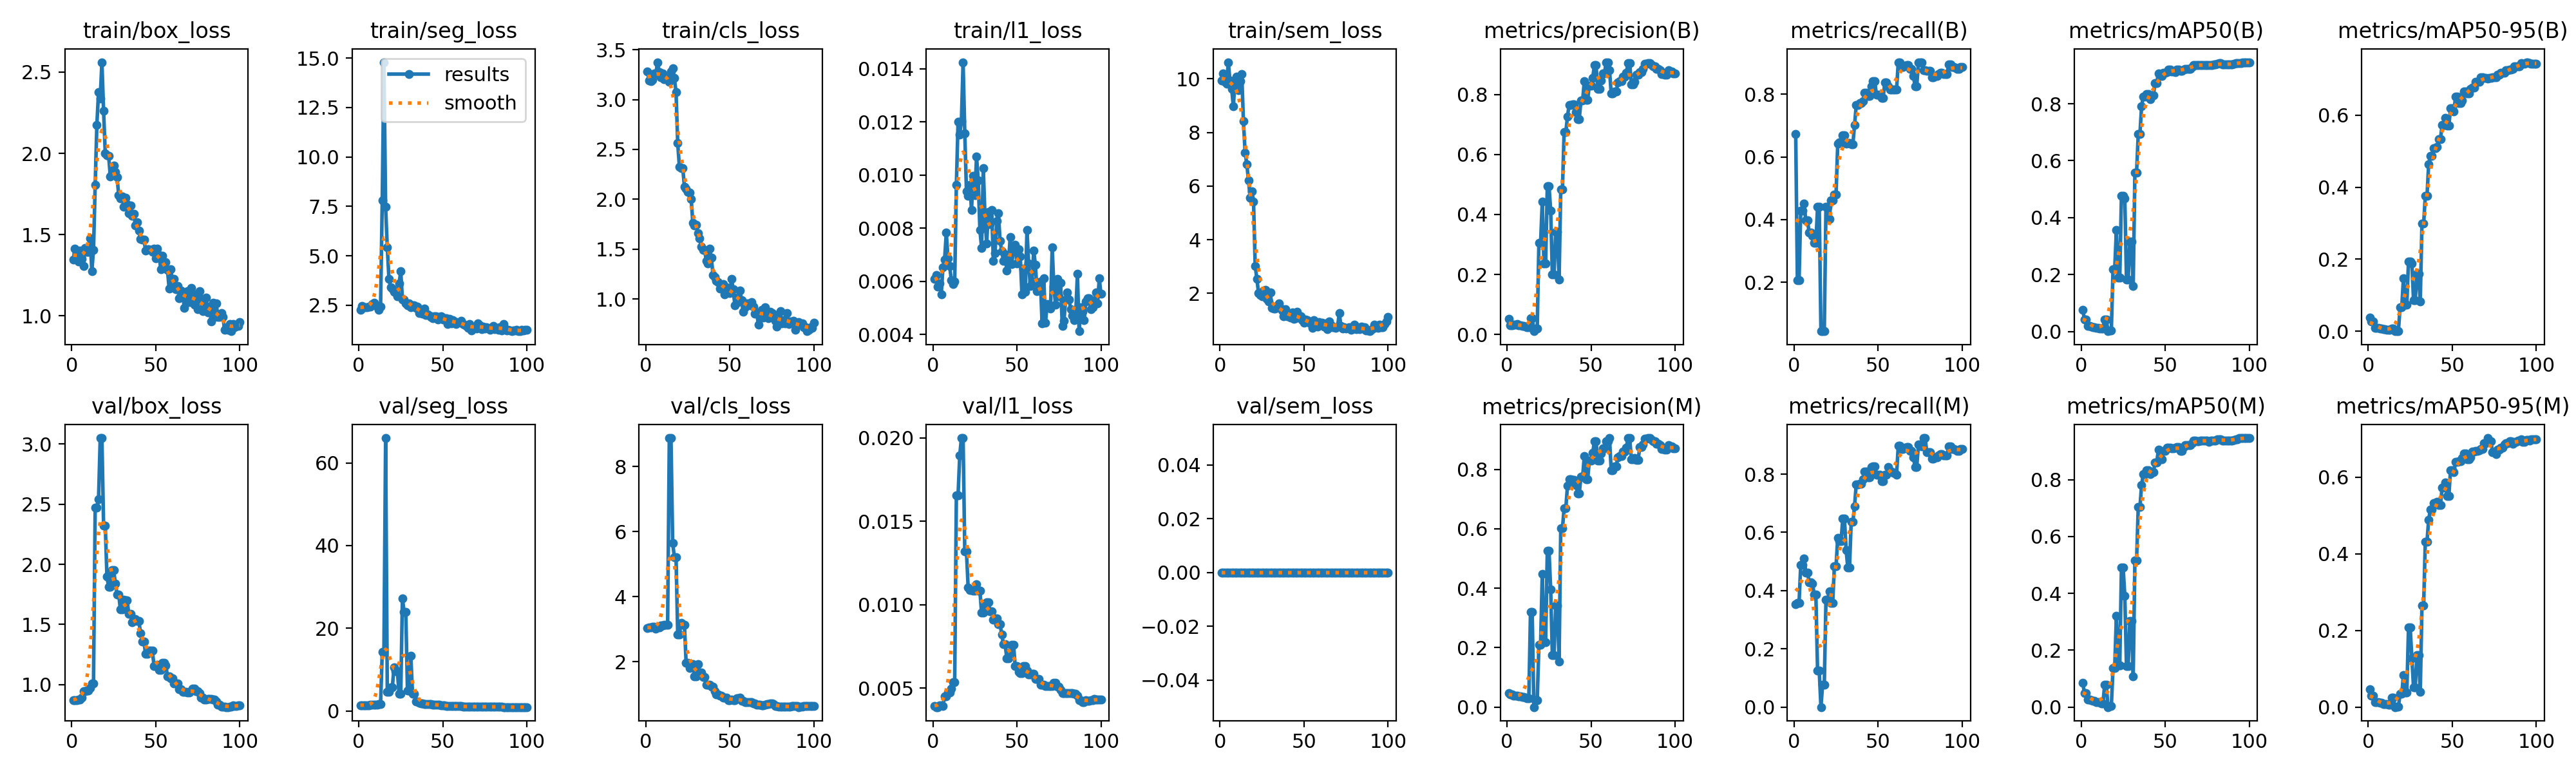

In [ ]:
from IPython.display import display, Image

curve_path = RUN_DIR / "results.png"
if curve_path.is_file():
    display(Image(filename=str(curve_path), width=1200))
else:
    print("Training curve not found:", curve_path)

### Optional validation previews
Regenerate the label/prediction comparison locally. These outputs contain source imagery and are not embedded in this publication copy.

In [ ]:
for filename in ["val_batch0_labels.jpg", "val_batch0_pred.jpg"]:
    path = RUN_DIR / filename
    if path.is_file():
        print(filename)
        display(Image(filename=str(path), width=1200))
    else:
        print("Not found:", path)

## 7. Qualitative video segmentation
Each frame is segmented independently. Instance colors can change between frames because no track IDs are used.

This preview uses GH010031 by default, which is represented in the training dataset. It is a qualitative demonstration. Each execution initializes a fresh model.

In [ ]:
import cv2
import math
import shutil
import torch

from pathlib import Path
from datetime import datetime
from ultralytics import YOLO

CONFIDENCE = DETECTION_CONF
OUTPUT_DIR = RUNS_DIR / "segmentation_previews"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------- Prepare local files --------
for path in [WEIGHTS, VIDEO_DRIVE]:
    if not path.is_file():
        raise FileNotFoundError(f"File not found: {path}")

LOCAL_DIR = Path("/content/salmon_segmentation_preview")
LOCAL_DIR.mkdir(parents=True, exist_ok=True)

local_video = LOCAL_DIR / VIDEO_DRIVE.name
local_weights = LOCAL_DIR / "best.pt"

shutil.copy2(VIDEO_DRIVE, local_video)
shutil.copy2(WEIGHTS, local_weights)

device = 0 if torch.cuda.is_available() else "cpu"
print("Device:", torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else "CPU")

model = YOLO(str(local_weights))

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
filename = f"{VIDEO_DRIVE.stem}_segmentation_{SECONDS}s_{timestamp}.mp4"

local_output = LOCAL_DIR / filename
drive_output = OUTPUT_DIR / filename

# -------- Process video --------
capture = cv2.VideoCapture(str(local_video))
writer = None
processed = 0

try:
    if not capture.isOpened():
        raise RuntimeError("Could not open the video.")

    fps = capture.get(cv2.CAP_PROP_FPS)
    if not math.isfinite(fps) or fps <= 0:
        raise RuntimeError("Could not read the video frame rate.")

    max_frames = max(1, round(fps * SECONDS))
    print(f"Processing up to {max_frames} frames ({SECONDS} seconds).")

    while processed < max_frames:
        success, frame = capture.read()

        if not success:
            break

        if writer is None:
            height, width = frame.shape[:2]
            output_width = width if OUTPUT_WIDTH is None else min(OUTPUT_WIDTH, width)
            output_height = round(height * output_width / width)

            output_width = max(2, output_width // 2 * 2)
            output_height = max(2, output_height // 2 * 2)
            output_size = (output_width, output_height)

            writer = cv2.VideoWriter(
                str(local_output),
                cv2.VideoWriter_fourcc(*"mp4v"),
                fps,
                output_size,
            )

            if not writer.isOpened():
                raise RuntimeError("Could not create the output video.")

        result = model.predict(
            source=frame,
            imgsz=IMAGE_SIZE,
            conf=CONFIDENCE,
            device=device,
            verbose=False,
            save=False,
        )[0]

        # Draw the predicted segmentation masks and boxes.
        annotated = result.plot(
            masks=True,
            boxes=True,
            labels=True,
            conf=True,
            color_mode="instance",
            line_width=2,
        )

        annotated = cv2.resize(
            annotated, output_size, interpolation=cv2.INTER_AREA
        )
        writer.write(annotated)

        processed += 1
        if processed % 30 == 0:
            print(f"Processed {processed}/{max_frames} frames", flush=True)

finally:
    capture.release()
    if writer is not None:
        writer.release()

if processed == 0:
    raise RuntimeError("No frames were processed.")

shutil.copy2(local_output, drive_output)

print(f"\nFinished: {processed} frames")
print(f"Output duration: approximately {processed / fps:.2f} seconds")
print(f"Video saved to:\n{drive_output}")

## 8. Segmentation with ByteTrack
ByteTrack associates predictions across consecutive frames. `persist=True` preserves tracker state. Colors follow track IDs, but the finite palette can repeat. Tracking does not smooth masks or guarantee permanent fish identity.

This preview uses GH010031 by default, which is represented in the training dataset. It is a qualitative demonstration. Each execution initializes a fresh model.

In [ ]:
import cv2
import math
import shutil
import torch

from pathlib import Path
from datetime import datetime
from ultralytics import YOLO

CONFIDENCE = TRACKING_CONF
OUTPUT_DIR = RUNS_DIR / "segmentation_tracking"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------- Prepare local files --------
for path in [WEIGHTS, VIDEO_DRIVE]:
    if not path.is_file():
        raise FileNotFoundError(f"File not found: {path}")

LOCAL_DIR = Path("/content/salmon_segmentation_tracking")
LOCAL_DIR.mkdir(parents=True, exist_ok=True)

local_video = LOCAL_DIR / VIDEO_DRIVE.name
local_weights = LOCAL_DIR / "best.pt"

shutil.copy2(VIDEO_DRIVE, local_video)
shutil.copy2(WEIGHTS, local_weights)

device = 0 if torch.cuda.is_available() else "cpu"
print(
    "Device:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available() else "CPU"
)

# A fresh model resets tracking state for each run.
model = YOLO(str(local_weights))

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
filename = f"{VIDEO_DRIVE.stem}_seg_tracking_{timestamp}.mp4"

local_output = LOCAL_DIR / filename
drive_output = OUTPUT_DIR / filename

capture = cv2.VideoCapture(str(local_video))
writer = None
processed = 0

try:
    if not capture.isOpened():
        raise RuntimeError("Could not open the video.")

    fps = capture.get(cv2.CAP_PROP_FPS)
    if not math.isfinite(fps) or fps <= 0:
        raise RuntimeError("Could not read the video frame rate.")

    max_frames = max(1, round(fps * SECONDS))
    print(f"Processing up to {max_frames} frames.")

    while processed < max_frames:
        success, frame = capture.read()

        if not success:
            break

        if writer is None:
            height, width = frame.shape[:2]

            output_width = width if OUTPUT_WIDTH is None else min(OUTPUT_WIDTH, width)
            output_height = round(height * output_width / width)

            output_width = max(2, output_width // 2 * 2)
            output_height = max(2, output_height // 2 * 2)
            output_size = (output_width, output_height)

            writer = cv2.VideoWriter(
                str(local_output),
                cv2.VideoWriter_fourcc(*"mp4v"),
                fps,
                output_size,
            )

            if not writer.isOpened():
                raise RuntimeError("Could not create the output video.")

        result = model.track(
            source=frame,
            persist=True,
            tracker="bytetrack.yaml",
            imgsz=IMAGE_SIZE,
            conf=CONFIDENCE,
            device=device,
            verbose=False,
            save=False,
        )[0]

        # Only render results with assigned tracking IDs.
        if result.boxes is not None and result.boxes.is_track:
            annotated = result.plot(
                masks=True,
                boxes=True,
                labels=True,
                conf=False,
                color_mode="instance",
                line_width=2,
            )
            active_tracks = len(result.boxes)
        else:
            annotated = frame.copy()
            active_tracks = 0

        annotated = cv2.resize(
            annotated,
            output_size,
            interpolation=cv2.INTER_AREA,
        )

        cv2.putText(
            annotated,
            f"Frame {processed + 1} | Visible tracks: {active_tracks}",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

        writer.write(annotated)
        processed += 1

        if processed % 30 == 0:
            print(
                f"Processed {processed}/{max_frames} frames",
                flush=True,
            )

finally:
    capture.release()
    if writer is not None:
        writer.release()

if processed == 0:
    raise RuntimeError("No frames were processed.")

shutil.copy2(local_output, drive_output)

print(f"\nFinished: {processed} frames")
print(f"Output duration: approximately {processed / fps:.2f} seconds")
print(f"Video saved to:\n{drive_output}")

## 9. Findings, limitations, and next steps

The original run produced useful masks and short-term fish tracks. Both preview modes processed 300 frames (approximately 10 seconds). The project author's visual assessment identified incomplete masks, frame-to-frame mask variation, and ID changes during overlap.

- **Segmentation:** occluded body parts are not expected to be reconstructed. Missing visible body regions are prediction errors.
- **Tracking:** IDs may switch or fragment; the largest ID is not a unique-fish count.
- **Evaluation:** video assessment is qualitative. No IDF1, HOTA, or independently annotated video-mask evaluation has been performed.
- **Sampling:** these 43 images do not represent the full diversity of farm conditions.
- **Application:** masks and tracks are not calibrated physical size, biomass, appetite, or welfare measurements.

Next steps are to obtain an independent test recording, expand annotations for difficult cases, and evaluate tracking against manually assigned ground-truth IDs. Keep independent test material out of iterative training and tuning.